In [13]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from src import candidates as c
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def show_side_by_side(
    images,
    titles=None,
    cmaps=None,
    figsize=(12, 5)
):
    """
    Display images side by side.

    Parameters
    ----------
    images : list of np.ndarray
        Images to display.
    titles : list of str, optional
        Titles for each image.
    cmaps : list of str or None, optional
        Colormaps (e.g. 'gray') per image.
    figsize : tuple
        Figure size.
    """
    n = len(images)
    titles = titles or [""] * n
    cmaps = cmaps or [None] * n

    fig, axes = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axes = [axes]

    for ax, img, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [16]:
image = cv2.imread('../data/test_ds/test1.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

bilateral = cv2.bilateralFilter(image, 9, 50, 50)  
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB) 
bil_gray_image = cv2.cvtColor(bilateral_rgb, cv2.COLOR_BGR2GRAY)

CANDIDATES

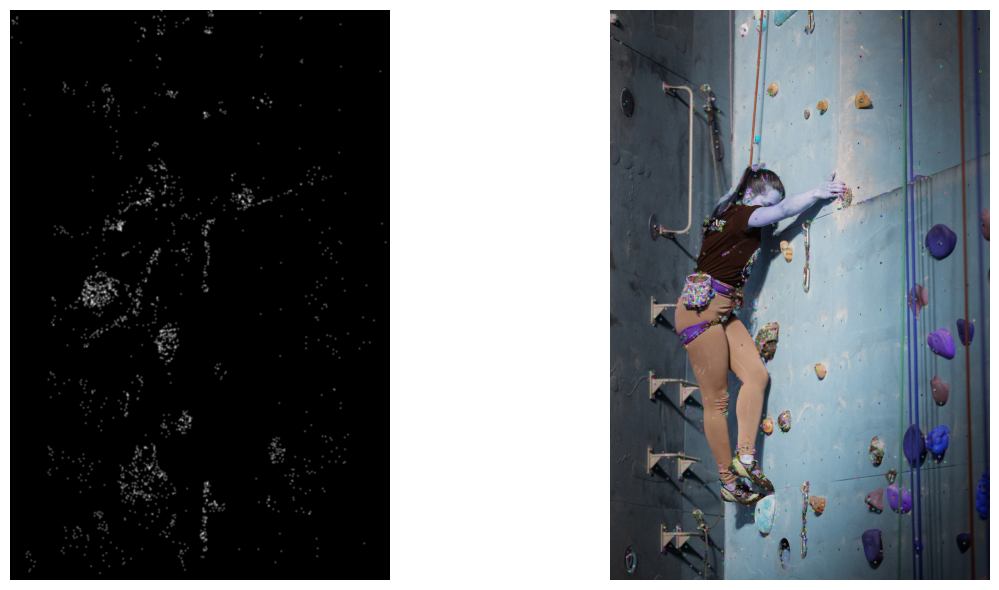

In [17]:

sift_heatmap, _ = c.sift_heatmap(bil_gray_image)

sift = cv2.SIFT_create()
keypoints, _ = sift.detectAndCompute(bil_gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)

show_side_by_side(
    images=[sift_heatmap, image_with_sift],
    cmaps=["gray", None],
    figsize=(14, 6)
)

Found 147 circles.


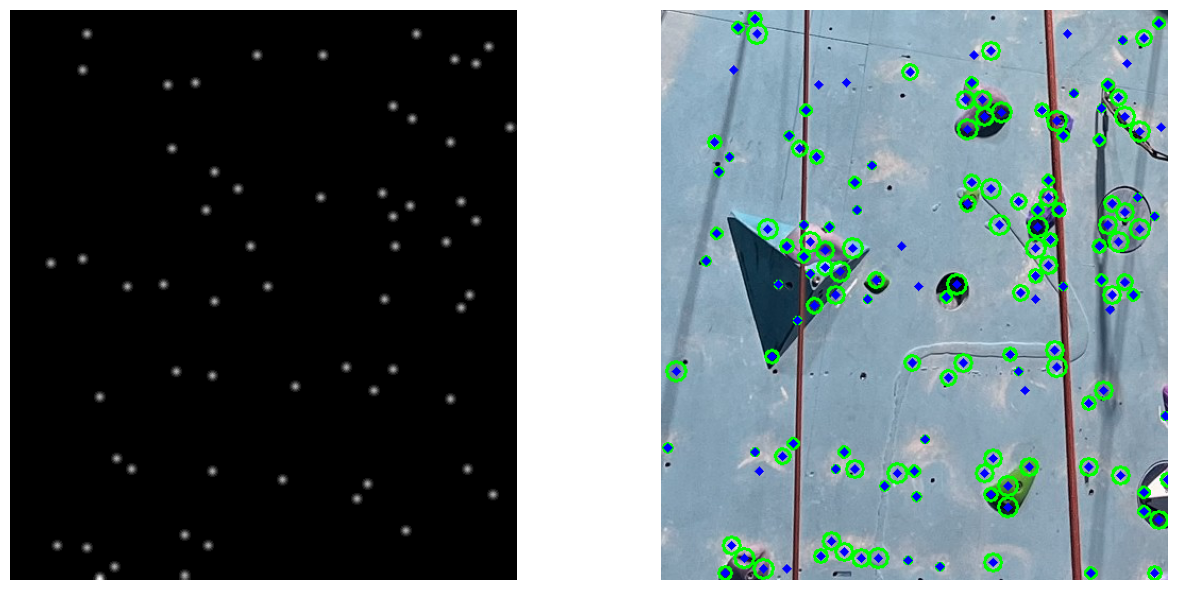

In [35]:
hough_heatmap, _ = c.hough_circles_heatmap(bil_gray_image)

circles = cv2.HoughCircles(
    bil_gray_image, 
    cv2.HOUGH_GRADIENT, # comments: accurate version for my initial photos: 1,15,50,6,1,3
    dp=1,           # 1
    minDist=15,     # 15
    param1=40,      # Edge sensitivity 50
    param2=8,       # 6
    minRadius=1,    # 1
    maxRadius=10     # 3
)

print(f"Found {len(circles[0])} circles.")
    
# Draw them to verify
output = image.copy()
circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
    cv2.circle(output, (i[0], i[1]), 2, (0, 0, 255), 3)

show_side_by_side(
    images=[hough_heatmap, output],
    cmaps=["gray", None],
    figsize=(14, 6)
)

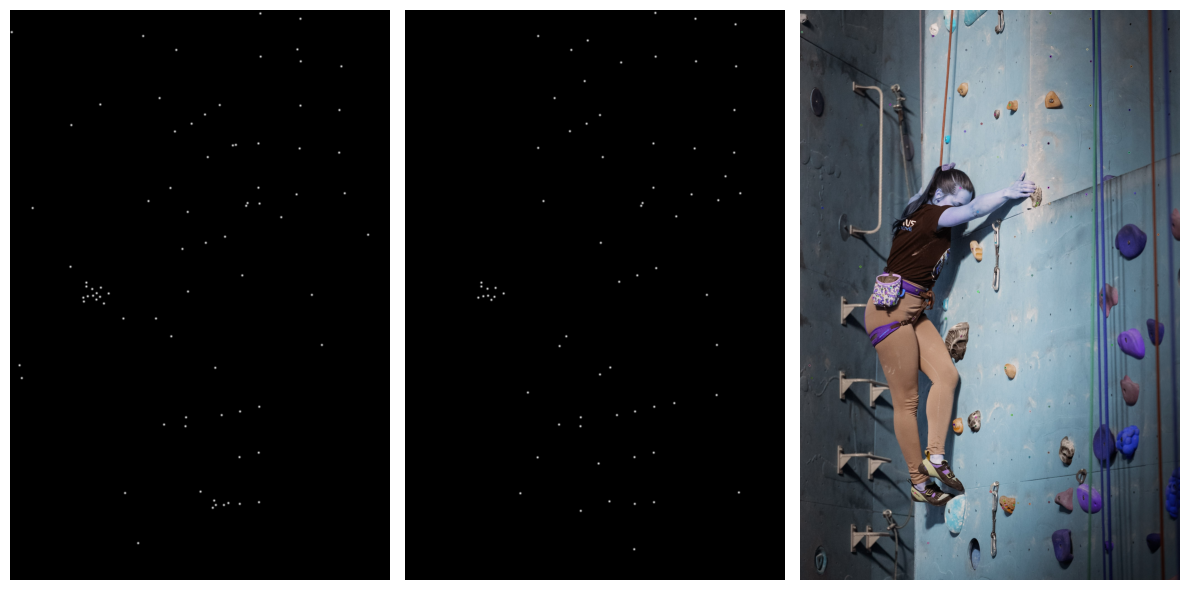

In [11]:
blob_heatmap, _ = c.blob_heatmap(gray_image)
blob_heatmap_bil, _ = c.blob_heatmap(bil_gray_image)

params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 10   
params.maxArea = 300

params.filterByCircularity = True
params.minCircularity = 0.6

params.filterByConvexity = True
params.minConvexity = 0.87

params.filterByInertia = True
params.minInertiaRatio = 0.5

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(gray_image)

image_with_blob = cv2.drawKeypoints(image, keypoints, None)

show_side_by_side(
    images=[blob_heatmap, blob_heatmap_bil, image_with_blob],
    cmaps=["gray", "gray", None],
    figsize=(12, 6)
)

In [12]:
len(keypoints)

81

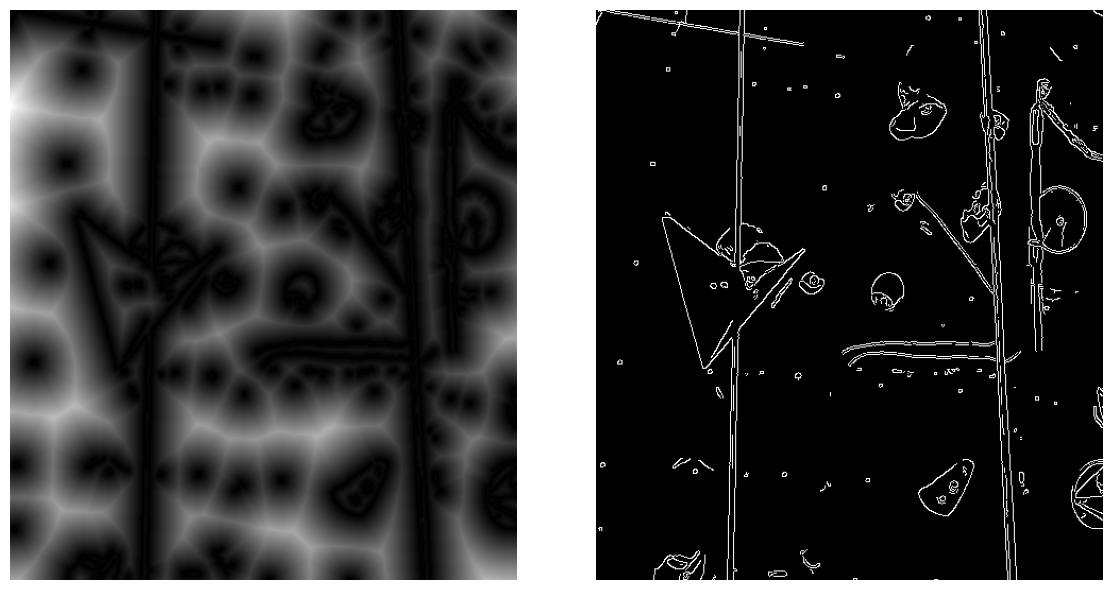

In [15]:
edges_canny = cv2.Canny(bil_gray_image, 100, 200)

distance_transform_heatmap = c.distance_transform_heatmap(edges_canny)

show_side_by_side(
    images=[distance_transform_heatmap, edges_canny],
    cmaps=["gray", "gray"],
    figsize=(12, 6)
)

FEATURES

In [7]:
import src.features as f
import src.utils as u

In [20]:
l = f.extract_features(image)
k = c.get_combined_candidates(image)